<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/Time-Series-and-Forecasting/TimeSeriesAndForecasting/Multi_Head_Self_Attention_and_Monte_Carlo_Simulation_for_Macro_Directional_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler

In [2]:
# --- CONFIGURATION ---
SEQ_LEN = 60        # Lookback window (60 days)
PREDICT_HORIZON = 1 # Predict next day
SPLIT_RATIO = 0.80  # Train/Test split
BATCH_SIZE = 32
EPOCHS = 50

In [3]:
# --- 1. DATA INGESTION ---
tickers = {
    'SPY': 'SPY',         # US Equities
    'VIX': '^VIX',        # Volatility
    '10Y': '^TNX',        # 10Y Yield
    '2Y': '^IRX',         # 2Y Yield (Short term rates)
    'DXY': 'DX-Y.NYB',    # US Dollar Index
    'OIL': 'CL=F'         # Crude Oil
}

print("📥 Downloading Macro Data...")
# Fetch data
raw_data = yf.download(list(tickers.values()), start='2005-01-01', end='2024-01-01', progress=False, auto_adjust=False)['Adj Close']
raw_data.columns = tickers.keys() # Rename columns nicely

# Forward fill to handle different market holidays (e.g., Oil vs Stocks)
raw_data.ffill(inplace=True)
raw_data.dropna(inplace=True)

raw_data.head()

📥 Downloading Macro Data...


,SPY,VIX,10Y,2Y,DXY,OIL
Date,,,,,,
2005-01-03,42.119999,81.300003,81.605995,2.204,4.220,14.08
2005-01-04,43.910000,82.570000,80.608833,2.292,4.283,13.98
2005-01-05,43.389999,82.540001,80.052536,2.282,4.277,14.09
2005-01-06,45.560001,83.150002,80.459587,2.267,4.272,13.58
2005-01-07,45.430000,83.610001,80.344269,2.277,4.285,13.49


In [4]:
# --- 2. FEATURE ENGINEERING & STATIONARITY ---
df = pd.DataFrame()

# A. Log Returns for Asset Prices (SPY, OIL, DXY)
# We use Log returns because they are additive and stationary
df['SPY_Ret'] = np.log(raw_data['SPY'] / raw_data['SPY'].shift(1))
df['OIL_Ret'] = np.log(raw_data['OIL'] / raw_data['OIL'].shift(1))
df['DXY_Ret'] = np.log(raw_data['DXY'] / raw_data['DXY'].shift(1))

# B. Differencing for Rates & Volatility (10Y, 2Y, VIX)
# These are already percentages, so we look at the *change* in percentage
df['VIX_Diff'] = raw_data['VIX'].diff()
df['10Y_Diff'] = raw_data['10Y'].diff()
df['Yield_Curve'] = raw_data['10Y'] - raw_data['2Y'] # The Recession Indicator
df['Curve_Diff'] = df['Yield_Curve'].diff()

# C. Target: 1 if SPY closes UP tomorrow, 0 if DOWN
df['Target'] = np.where(df['SPY_Ret'].shift(-1) > 0, 1, 0)

# Drop NaNs created by shifting/diffing
df.dropna(inplace=True)

print(f"✅ Data Processed. Shape: {df.shape}")
print(df.head())

✅ Data Processed. Shape: (4785, 8)
             SPY_Ret   OIL_Ret   DXY_Ret  VIX_Diff  10Y_Diff  Yield_Curve  \
Date                                                                        
2005-01-04  0.041619 -0.007128  0.014819  1.269997 -0.997162    78.316833   
2005-01-05 -0.011913  0.007838 -0.001402 -0.029999 -0.556297    77.770536   
2005-01-06  0.048801 -0.036867 -0.001170  0.610001  0.407051    78.192587   
2005-01-07 -0.002857 -0.006649  0.003038  0.459999 -0.115318    78.067269   
2005-01-10 -0.002204 -0.019462 -0.001635 -0.320000  0.379860    78.451129   

            Curve_Diff  Target  
Date                            
2005-01-04   -1.085162       0  
2005-01-05   -0.546297       1  
2005-01-06    0.422051       0  
2005-01-07   -0.125318       0  
2005-01-10    0.383860       1  


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [5]:
# --- 3. SCALING ---
feature_cols = [c for c in df.columns if c != 'Target']
scaler = StandardScaler()

# We fit the scaler ONLY on the training portion to prevent data leakage
train_size = int(len(df) * SPLIT_RATIO)
df_train = df.iloc[:train_size]
df_test = df.iloc[train_size:]

# Fit on Train, Transform both
X_scaled_train = scaler.fit_transform(df_train[feature_cols])
X_scaled_test = scaler.transform(df_test[feature_cols])

# Targets
y_train_raw = df_train['Target'].values
y_test_raw = df_test['Target'].values

In [6]:
# --- 4. CREATE ROLLING WINDOW DATASETS (From Scratch) ---
def create_dataset(X, y, lookback=60):
    X_out, y_out = [], []
    for i in range(lookback, len(X)):
        X_out.append(X[i-lookback:i]) # Grab 60 days
        y_out.append(y[i])            # Grab target at day i
    return np.array(X_out), np.array(y_out)

print("🛠️ Building Rolling Windows...")
X_train, y_train = create_dataset(X_scaled_train, y_train_raw, SEQ_LEN)
X_test, y_test = create_dataset(X_scaled_test, y_test_raw, SEQ_LEN)

# Verify Shapes
# Shape: (Samples, Time Steps, Features)
print(f"Train Input Shape: {X_train.shape}")
print(f"Test Input Shape:  {X_test.shape}")

🛠️ Building Rolling Windows...
Train Input Shape: (3768, 60, 7)
Test Input Shape:  (897, 60, 7)


In [7]:
# --- 5. DEFINE TRANSFORMER BLOCK ---
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # A. Layer Norm + Attention
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(x, x)

    # Residual Connection (Add input to output)
    res = layers.Add()([x, inputs])

    # B. Layer Norm + Feed Forward (Conv1D)
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)

    # Residual Connection
    return layers.Add()([x, res])

In [8]:
# --- 6. BUILD FULL MODEL ---
def build_alphaformer(input_shape, num_heads=4, head_size=64, ff_dim=128):
    inputs = layers.Input(shape=input_shape)

    # 1. Transformer Encoder Blocks (Stacked)
    x = transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1)
    x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout=0.1)
    x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout=0.1)

    # 2. Global Average Pooling
    # "Smash" the 60 days of attention-weighted data into one vector
    x = layers.GlobalAveragePooling1D()(x)

    # 3. Classification Head (MLP)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="AlphaFormer")
    return model

In [9]:
# Instantiate
input_shape = (X_train.shape[1], X_train.shape[2]) # (60, Features)
model = build_alphaformer(input_shape)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Low LR for Transformers
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "AlphaFormer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 60, 7)     │         14 │ input_layer[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 7)     │      7,943 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 60, 7)     │          0 │ multi_head_atten… │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 7)     │         14 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 60, 128)   │      1,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 60, 128)   │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 60, 7)     │        903 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 60, 7)     │          0 │ conv1d_1[0][0],   │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 7)     │         14 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 7)     │      7,943 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 60, 7)     │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 7)     │         14 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 60, 128)   │      1,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 60, 128)   │          0 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 60, 7)     │        903 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 60, 7)     │          0 │ conv1d_3[0][0],   │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 7)     │         14 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 7)     │      7,943 │ layer_normalizat

 Total params: 30,271 (118.25 KB)

 Trainable params: 30,271 (118.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# --- 7. TRAINING ---
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[
        callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(patience=5, factor=0.5, verbose=1)
    ],
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 32s 229ms/step - accuracy: 0.4987 - loss: 0.7086 - val_accuracy: 0.4504 - val_loss: 0.7618 - learning_rate: 1.0000e-04
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5026 - loss: 0.6971 - val_accuracy: 0.4526 - val_loss: 0.7303 - learning_rate: 1.0000e-04
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5226 - loss: 0.6920 - val_accuracy: 0.4526 - val_loss: 0.7208 - learning_rate: 1.0000e-04
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5077 - loss: 0.6931 - val_accuracy: 0.4515 - val_loss: 0.7267 - learning_rate: 1.0000e-04
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5016 - loss: 0.6925 - val_accuracy: 0.4515 - val_loss: 0.7251 - learning_rate: 1.0000e-04
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5150 - loss: 0.6925 - val_accuracy: 0.4537 - val_loss: 0.7190 - learning_rate: 1.0000e-04
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.516

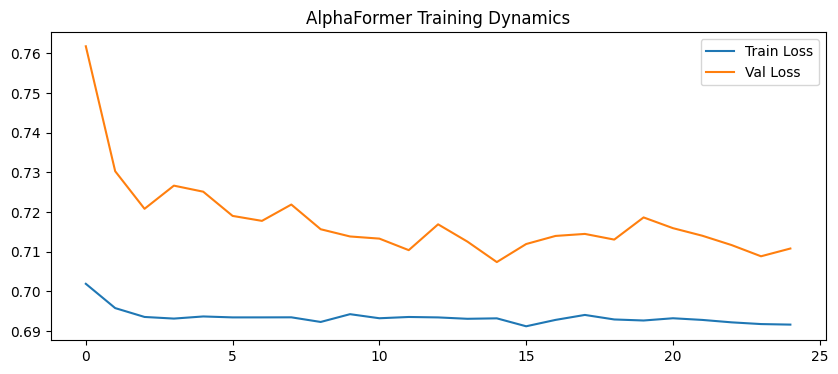

In [11]:
# Plot Loss Curves
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("AlphaFormer Training Dynamics")
plt.legend()
plt.show()

In [12]:
# --- 8. BACKTEST SIMULATION ---
print("📊 Running Backtest...")

# Generate Probabilities
probs = model.predict(X_test).flatten()

# Prepare Dataframe for Analysis
# We need to align the dates correctly.
# X_test starts at index: train_size + SEQ_LEN
test_indices = df.index[train_size + SEQ_LEN:]
bt_df = pd.DataFrame({'Target': y_test, 'Prob': probs}, index=test_indices)

# Add Raw Returns for PnL Calc (Unscaled)
# We use the original dataframe's returns
bt_df['SPY_Ret'] = df.loc[test_indices, 'SPY_Ret']

# Strategy Logic
# Long if Prob > 0.55, Short if Prob < 0.45, else Cash
bt_df['Position'] = np.where(bt_df['Prob'] > 0.55, 1,
                             np.where(bt_df['Prob'] < 0.45, -1, 0))

# Shift Position (Trade Tomorrow based on Today's signal)
bt_df['Position'] = bt_df['Position'].shift(1).fillna(0)

# Calculate Returns (Net of 5bps transaction cost)
cost = 0.0005
bt_df['Strat_Ret_Gross'] = bt_df['Position'] * bt_df['SPY_Ret']
bt_df['Trades'] = bt_df['Position'].diff().abs()
bt_df['Strat_Ret_Net'] = bt_df['Strat_Ret_Gross'] - (bt_df['Trades'] * cost)

# Cumulative Returns (Equity Curves)
bt_df['Equity_Strat'] = (1 + bt_df['Strat_Ret_Net']).cumprod()
bt_df['Equity_BuyHold'] = (1 + bt_df['SPY_Ret']).cumprod()

bt_df.head()

📊 Running Backtest...
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step


,Target,Prob,SPY_Ret,Position,Strat_Ret_Gross,Trades,Strat_Ret_Net,Equity_Strat,Equity_BuyHold
Date,,,,,,,,,
2020-06-09,1,0.492292,0.019448,0.0,0.0,NaN,NaN,NaN,1.019448
2020-06-10,0,0.510355,0.016807,0.0,0.0,0.0,0.0,1.0,1.036582
2020-06-11,0,0.542565,-0.085910,0.0,-0.0,0.0,-0.0,1.0,0.947529
2020-06-12,1,0.500199,-0.002204,0.0,-0.0,0.0,-0.0,1.0,0.945441
2020-06-15,1,0.530687,0.023441,0.0,0.0,0.0,0.0,1.0,0.967603


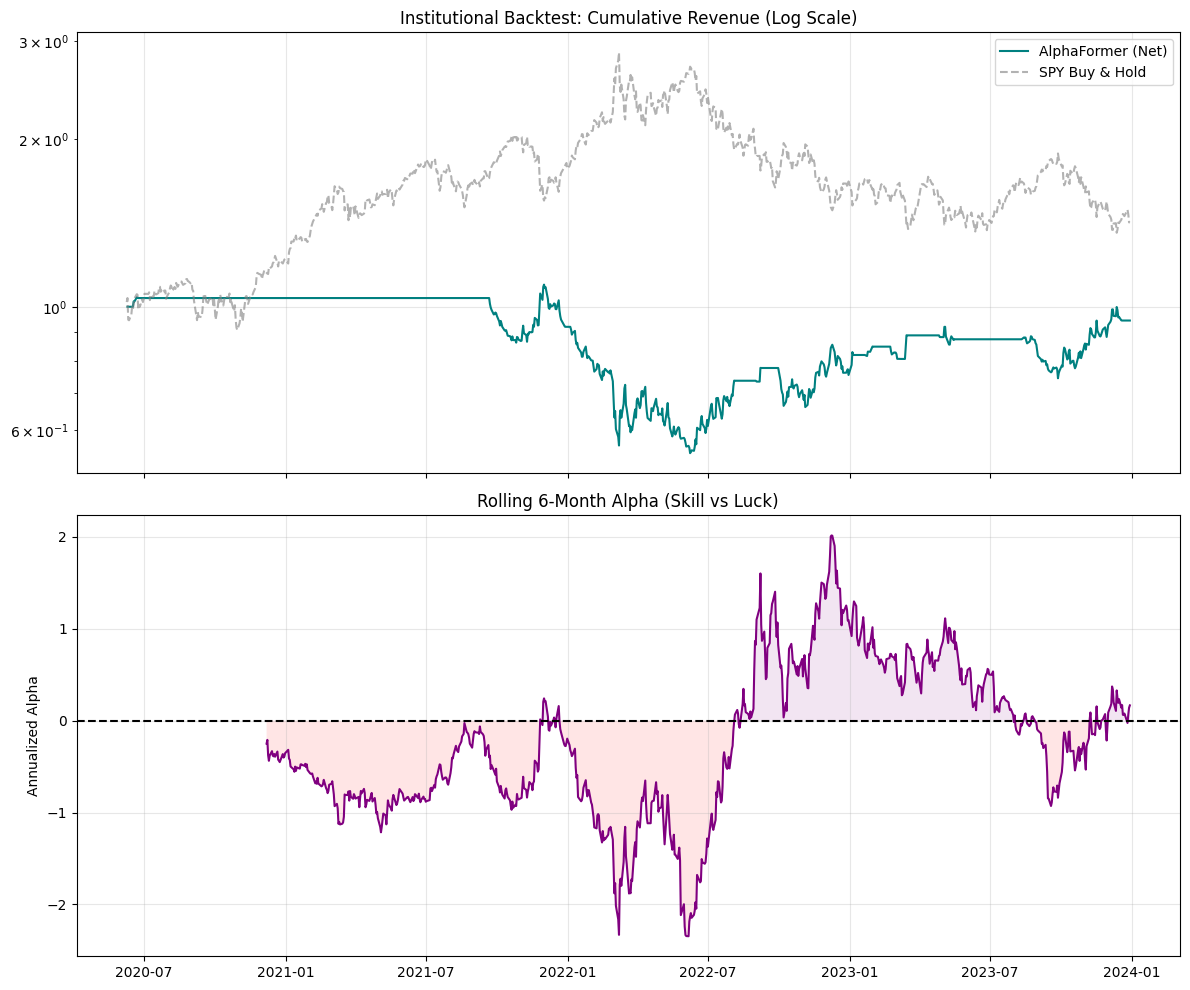

In [13]:
# --- 9. VISUALIZATION: REVENUE & ALPHA ---
fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot 1: Revenue (Log Scale)
ax[0].plot(bt_df['Equity_Strat'], label='AlphaFormer (Net)', color='teal')
ax[0].plot(bt_df['Equity_BuyHold'], label='SPY Buy & Hold', color='gray', linestyle='--', alpha=0.6)
ax[0].set_yscale('log')
ax[0].set_title('Institutional Backtest: Cumulative Revenue (Log Scale)')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Plot 2: Rolling Alpha
# Alpha = Strategy - Benchmark
bt_df['Alpha'] = bt_df['Strat_Ret_Net'] - bt_df['SPY_Ret']
rolling_alpha = bt_df['Alpha'].rolling(126).mean() * 252 # Annualized

ax[1].plot(rolling_alpha, color='purple', linewidth=1.5)
ax[1].axhline(0, color='black', linestyle='--')
ax[1].fill_between(bt_df.index, rolling_alpha, 0, where=(rolling_alpha>0), facecolor='purple', alpha=0.1)
ax[1].fill_between(bt_df.index, rolling_alpha, 0, where=(rolling_alpha<0), facecolor='red', alpha=0.1)
ax[1].set_title('Rolling 6-Month Alpha (Skill vs Luck)')
ax[1].set_ylabel('Annualized Alpha')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# --- 10. METRICS ---
sharpe = bt_df['Strat_Ret_Net'].mean() / bt_df['Strat_Ret_Net'].std() * np.sqrt(252)
dd = (bt_df['Equity_Strat'] / bt_df['Equity_Strat'].cummax() - 1).min()

print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Max Drawdown: {dd*100:.2f}%")

Sharpe Ratio: 0.09
Max Drawdown: -50.24%


In [15]:
# --- 11. ATTENTION PROXY VISUALIZATION ---
# Since extracting internal weights from `MultiHeadAttention` in Keras
# is complex without subclassing, we visualize the SELF-SIMILARITY of the input
# which is the foundation of self-attention.

def visualize_input_similarity(model, x_sample):
    # 1. Extract the encoded features (Output of the first Transformer Block)
    # This shows us how the model "transformed" the data
    # We grab the output of the first "Add" layer (after Block 1)
    target_layer = [l for l in model.layers if 'add' in l.name][0]
    intermediate = models.Model(inputs=model.input, outputs=target_layer.output)

    features = intermediate.predict(x_sample) # Shape: (1, 60, 64)
    q = features[0] # (60, 64)

    # 2. Compute Self-Attention Map (Dot Product)
    # Q * Q^T
    attn_map = np.matmul(q, q.T)

    # Normalize
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())

    plt.figure(figsize=(10, 8))
    sns.heatmap(attn_map, cmap='magma', xticklabels=5, yticklabels=5)
    plt.title("Self-Attention Proxy: Temporal Correlations")
    plt.xlabel("Day (Context)")
    plt.ylabel("Day (Current)")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step


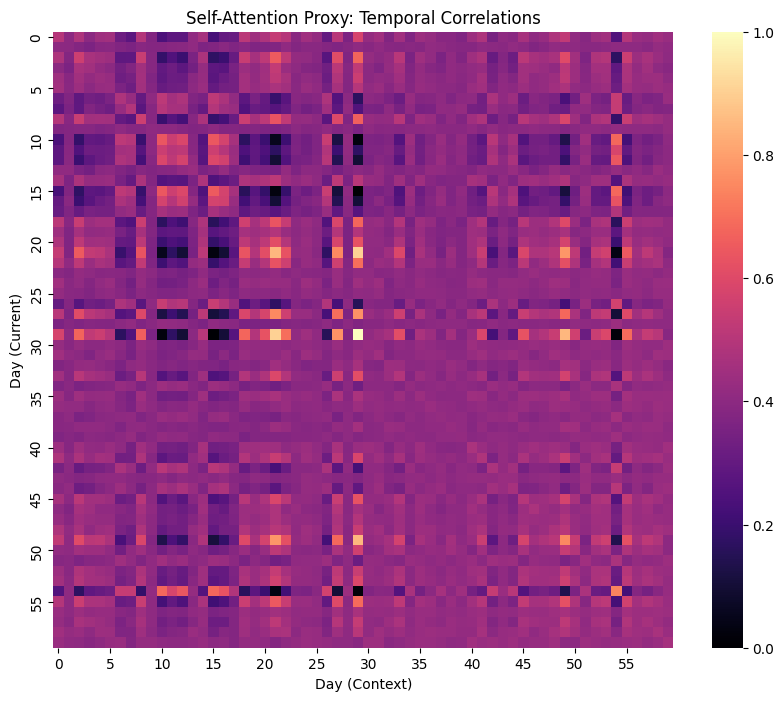

In [16]:
visualize_input_similarity(model, X_test[-1:])

In [17]:
# --- 12. MONTE CARLO DROPOUT (UNCERTAINTY ESTIMATION) ---
import numpy as np
from tqdm import tqdm

def predict_with_uncertainty(model, X, n_iter=100):
    """
    Runs inference n_iter times with Dropout ENABLED.
    Returns:
        - prediction_mean: The average probability (Robust Signal)
        - prediction_std: The standard deviation (Uncertainty/Risk)
    """
    # Force 'training=True' to keep Dropout active
    # We iterate through the batch to avoid memory overload if X is huge
    preds = []

    print(f"🎲 Running Monte Carlo Simulation ({n_iter} iterations)...")
    for _ in tqdm(range(n_iter)):
        # Call model directly with training=True
        # Shape: (Samples, 1)
        p = model(X, training=True)
        preds.append(p)

    # Stack into shape: (n_iter, Samples, 1)
    preds = np.array(preds)

    # Calculate Statistics
    prediction_mean = preds.mean(axis=0).flatten() # The "Ensemble" Prediction
    prediction_std = preds.std(axis=0).flatten()   # The "Uncertainty"

    return prediction_mean, prediction_std, preds

# Run on Test Set
mc_mean, mc_std, mc_raw = predict_with_uncertainty(model, X_test, n_iter=50)

print(f"\nExample Prediction (Last Day):")
print(f"Mean Probability: {mc_mean[-1]:.4f}")
print(f"Uncertainty (Std): {mc_std[-1]:.4f}")
print(f"95% Confidence Interval: {mc_mean[-1] - 1.96*mc_std[-1]:.4f} to {mc_mean[-1] + 1.96*mc_std[-1]:.4f}")

🎲 Running Monte Carlo Simulation (50 iterations)...


100%|██████████| 50/50 [00:06<00:00,  7.89it/s]


Example Prediction (Last Day):
Mean Probability: 0.4668
Uncertainty (Std): 0.0791
95% Confidence Interval: 0.3117 to 0.6219


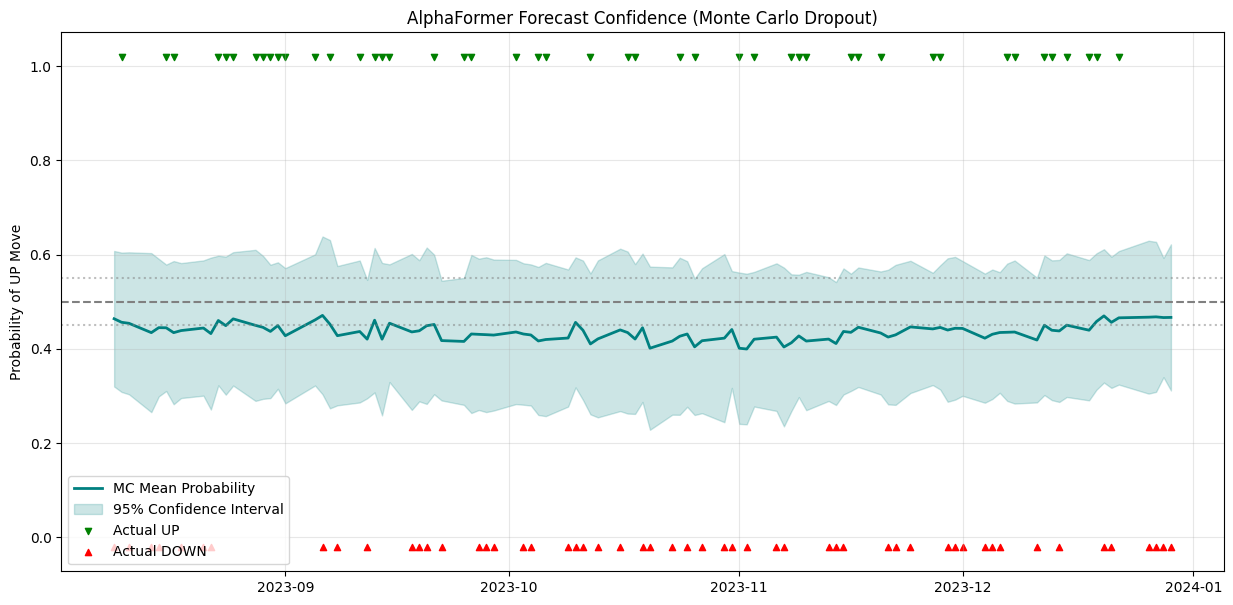

In [18]:
# --- 13. VISUALIZING CONFIDENCE INTERVALS ---

# Select a window to plot (e.g., last 100 days)
zoom = 100
dates = test_indices[-zoom:]
mean_zoom = mc_mean[-zoom:]
std_zoom = mc_std[-zoom:]
true_target = y_test[-zoom:]

plt.figure(figsize=(15, 7))

# 1. Plot the Mean Prediction (The Line)
plt.plot(dates, mean_zoom, color='teal', label='MC Mean Probability', linewidth=2)

# 2. Plot the 95% Confidence Interval (The Band)
# CI = Mean +/- 1.96 * Std
lower_bound = np.maximum(0, mean_zoom - 1.96 * std_zoom) # Cap at 0
upper_bound = np.minimum(1, mean_zoom + 1.96 * std_zoom) # Cap at 1

plt.fill_between(dates, lower_bound, upper_bound, color='teal', alpha=0.2, label='95% Confidence Interval')

# 3. Overlay Actual Target (Did it go up?)
# We scale the binary target to overlay nicely (0.05 and 0.95 purely for visual)
# Up days = Green dots, Down days = Red dots
up_days = dates[true_target == 1]
down_days = dates[true_target == 0]
plt.scatter(up_days, [1.02]*len(up_days), color='green', marker='v', s=20, label='Actual UP')
plt.scatter(down_days, [-0.02]*len(down_days), color='red', marker='^', s=20, label='Actual DOWN')

# 4. Decision Threshold
plt.axhline(0.5, color='gray', linestyle='--')
plt.axhline(0.55, color='gray', linestyle=':', alpha=0.5)
plt.axhline(0.45, color='gray', linestyle=':', alpha=0.5)

plt.title("AlphaFormer Forecast Confidence (Monte Carlo Dropout)")
plt.ylabel("Probability of UP Move")
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

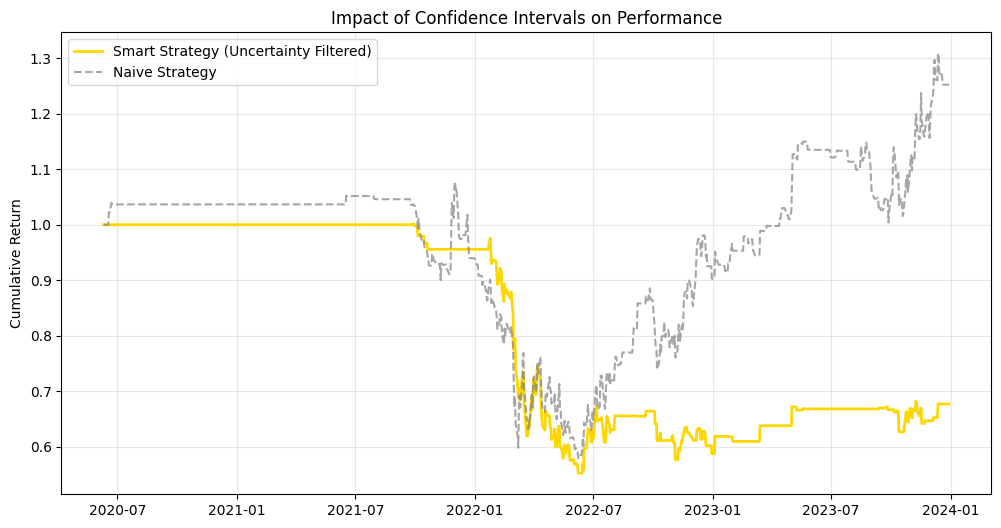

Sharpe (Naive): 0.36
Sharpe (Smart): -0.43


In [19]:
# --- 14. UNCERTAINTY-ADJUSTED BACKTEST ---

# Create DataFrame
risk_df = pd.DataFrame({
    'Target': y_test,
    'Prob_Mean': mc_mean,
    'Uncertainty': mc_std,
    'SPY_Ret': df.loc[test_indices, 'SPY_Ret']
}, index=test_indices)

# STRATEGY 1: Naive (Trade purely on Probability)
risk_df['Pos_Naive'] = np.where(risk_df['Prob_Mean'] > 0.55, 1,
                                np.where(risk_df['Prob_Mean'] < 0.45, -1, 0))

# STRATEGY 2: Smart (Filter by Confidence)
# We only trade if the Lower Bound of our confidence is still bullish
# i.e., Mean - 1 Std > 0.5
risk_df['Pos_Smart'] = np.where((risk_df['Prob_Mean'] - risk_df['Uncertainty']) > 0.5, 1,
                                np.where((risk_df['Prob_Mean'] + risk_df['Uncertainty']) < 0.5, -1, 0))

# Shift (Trade tomorrow)
risk_df['Pos_Naive'] = risk_df['Pos_Naive'].shift(1).fillna(0)
risk_df['Pos_Smart'] = risk_df['Pos_Smart'].shift(1).fillna(0)

# Calculate Returns
cost = 0.0005
risk_df['Ret_Naive'] = risk_df['Pos_Naive'] * risk_df['SPY_Ret'] - (risk_df['Pos_Naive'].diff().abs() * cost)
risk_df['Ret_Smart'] = risk_df['Pos_Smart'] * risk_df['SPY_Ret'] - (risk_df['Pos_Smart'].diff().abs() * cost)

# Cumulative
risk_df['Eq_Naive'] = (1 + risk_df['Ret_Naive']).cumprod()
risk_df['Eq_Smart'] = (1 + risk_df['Ret_Smart']).cumprod()

# Plot Comparison
plt.figure(figsize=(12, 6))
plt.plot(risk_df['Eq_Smart'], label='Smart Strategy (Uncertainty Filtered)', color='gold', linewidth=2)
plt.plot(risk_df['Eq_Naive'], label='Naive Strategy', color='gray', linestyle='--', alpha=0.7)
plt.title("Impact of Confidence Intervals on Performance")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Metrics
sharpe_smart = risk_df['Ret_Smart'].mean() / risk_df['Ret_Smart'].std() * np.sqrt(252)
sharpe_naive = risk_df['Ret_Naive'].mean() / risk_df['Ret_Naive'].std() * np.sqrt(252)
print(f"Sharpe (Naive): {sharpe_naive:.2f}")
print(f"Sharpe (Smart): {sharpe_smart:.2f}")